# atlm_pro — Dataset Exploration

**Project goal.** Fine-tune a small instruction model (SmolLM) so that a
recruiter's loose requirements — e.g. *"I need a job description for someone who
knows Java, pipelines and CI/CD"* — produce a complete, well-formatted job
description.

**This notebook** explores the candidate datasets and justifies which one(s) the
project will use. Three datasets are examined:

1. The **original synthetic CSV** that was provided with the project.
2. **Djinni** — real IT job postings (Hugging Face).
3. **LinkedIn** — real cross-industry job postings (Kaggle).

## 0. Setup

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 120)

# Locate the project root (the folder that contains data/).
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "data").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
JOBS = PROJECT_ROOT / "data" / "jobs"

print("Project root :", PROJECT_ROOT)
print("Jobs data dir:", JOBS)
assert JOBS.exists(), f"data/jobs not found starting from {Path.cwd()}"

Project root : /home/logus/env/iscte/atlm_pro
Jobs data dir: /home/logus/env/iscte/atlm_pro/data/jobs


## 1. The original synthetic dataset

A CSV of job postings was provided in `data/jobs/hf/job_descriptions.csv`
(~1.6M rows). Before building anything on it we need one question answered:
**how many genuinely distinct job descriptions does it contain?** — because that,
not the row count, is the real training signal for a generation model.

In [2]:
synthetic_csv = JOBS / "hf" / "job_descriptions.csv"

# Peek at the schema with a tiny read.
preview = pd.read_csv(synthetic_csv, nrows=3)
print(f"{preview.shape[1]} columns:")
for i, col in enumerate(preview.columns):
    print(f"  {i:2d}. {col}")

preview.head(3).T

23 columns:
   0. Job Id
   1. Experience
   2. Qualifications
   3. Salary Range
   4. location
   5. Country
   6. latitude
   7. longitude
   8. Work Type
   9. Company Size
  10. Job Posting Date
  11. Preference
  12. Contact Person
  13. Contact
  14. Job Title
  15. Role
  16. Job Portal
  17. Job Description
  18. Benefits
  19. skills
  20. Responsibilities
  21. Company
  22. Company Profile


,0,1,2
Job Id,1089843540111562,398454096642776,481640072963533
Experience,5 to 15 Years,2 to 12 Years,0 to 12 Years
Qualifications,M.Tech,BCA,PhD
Salary Range,$59K-$99K,$56K-$116K,$61K-$104K
location,Douglas,Ashgabat,Macao
Country,Isle of Man,Turkmenistan,"Macao SAR, China"
latitude,54.2361,38.9697,22.1987
longitude,-4.5481,59.5563,113.5439
Work Type,Intern,Intern,Temporary
Company Size,26801,100340,84525


The columns split into two groups:

- **Free text** — `Job Title`, `Role`, `Job Description`, `skills`,
  `Responsibilities`. This is what a generator would have to produce.
- **Structured metadata** — salary, location, company, contact, dates, etc.
  Not part of what the model generates from a recruiter query.

So the diversity that matters is the diversity of the *free-text* fields.

In [3]:
# Read only the text fields a generation model would have to produce.
text_cols = ["Job Title", "Role", "Job Description", "skills", "Responsibilities"]
syn = pd.read_csv(synthetic_csv, usecols=text_cols, dtype=str)

print(f"Total rows: {len(syn):,}\n")
for col in text_cols:
    print(f"  unique {repr(col):22}: {syn[col].nunique():>10,}")

Total rows: 1,615,940

  unique 'Job Title'           :        147
  unique 'Role'                :        376
  unique 'Job Description'     :        376
  unique 'skills'              :        376
  unique 'Responsibilities'    :        375


### Finding: the data is templated

Despite ~1.6M rows there are only **376 distinct job descriptions** — and the
`skills` and `Responsibilities` fields are equally repetitive. Each `Role` maps to
exactly **one** fixed description string, copied verbatim across tens of thousands
of rows. The 1.6M rows are that lookup table of 376 text bundles, inflated by
attaching varying metadata.

**Implication.** For a generation model the effective training set is ~376 unique
targets, not 1.6M. Training on it would just teach the model to memorise 376
strings. This dataset is **not suitable** as-is; it is kept only as a baseline
reference.

In [4]:
role = "Frontend Web Developer"
sub = syn[syn["Role"] == role]
print(f"Role {role!r}")
print(f"  rows                    : {len(sub):,}")
print(f"  distinct Job Description: {sub['Job Description'].nunique()}")
print(f"  distinct skills         : {sub['skills'].nunique()}")
print()
print("The single description, repeated for every one of those rows:")
print(" ", sub["Job Description"].iloc[0][:300], "...")

Role 'Frontend Web Developer'
  rows                    : 3,563
  distinct Job Description: 1
  distinct skills         : 1

The single description, repeated for every one of those rows:
  Frontend Web Developers design and implement user interfaces for websites, ensuring they are visually appealing and user-friendly. They collaborate with designers and backend developers to create seamless web experiences for users. ...


## 2. Djinni — the core dataset

[`lang-uk/recruitment-dataset-job-descriptions-english`](https://huggingface.co/datasets/lang-uk/recruitment-dataset-job-descriptions-english)
— real IT job postings scraped from the Djinni platform (2020–2023), MIT-licensed.
This is the **core dataset** for training, validation and in-domain testing.

In [5]:
djinni = pd.read_parquet(JOBS / "djinni" / "train-00000-of-00001.parquet")
djinni = djinni.drop(columns=["__index_level_0__"], errors="ignore")

print(f"shape: {djinni.shape[0]:,} rows x {djinni.shape[1]} columns\n")
djinni.dtypes

shape: 141,897 rows x 9 columns



Position                 str
Long Description         str
Company Name             str
Exp Years                str
Primary Keyword          str
English Level            str
Published                str
Long Description_lang    str
id                       str
dtype: object

In [6]:
n_unique = djinni["Long Description"].nunique()
print(f"unique 'Long Description': {n_unique:,}  ({n_unique / len(djinni):.1%} of rows)")
djinni.head(3)

unique 'Long Description': 141,897  (100.0% of rows)


,Position,Long Description,Company Name,Exp Years,Primary Keyword,English Level,Published,Long Description_lang,id
0,10 + Blockchain Nodes / Masternodes to set up,"*Requirements*\r\n\r\nWe're looking for a long term collaboration with someone that has an experience in crypto, mas...",MyCointainer,2y,Sysadmin,intermediate,2020-10-01T00:00:00+03:00,en,c0ca96e7-85df-50df-a64e-d934cd02a170
1,10 .NET Developers (Middle and Senior level),"Greetings! My name is Maria, I am in urgent need to find a team of 10 .NET Developers (Middle and Senior level) to j...",TechScout.tech,2y,.NET,intermediate,2022-03-01T00:00:00+02:00,en,64f4b7ea-36e4-5bdd-a8b1-185f32f7dc7f
2,"10X Engineer (co-founder, #4 employee, USD 11-12k, 1-4% equity)",**Product**\r\nThe product is a live video chat and co-browsing with website visitors. It helps companies generate m...,Innoteka,5y,JavaScript,fluent,2021-07-01T00:00:00+03:00,en,b9a1303e-dd0c-5ed1-8f62-be2bc4c7da4f


count    141897.0
mean       1801.0
std         973.0
min          51.0
25%        1109.0
50%        1629.0
75%        2284.0
max       12578.0
Name: Long Description, dtype: float64


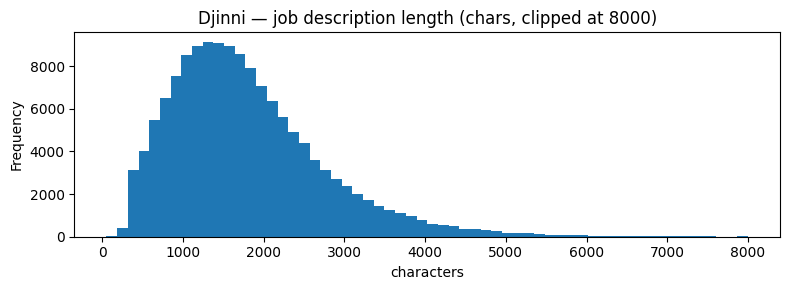

In [7]:
lengths = djinni["Long Description"].str.len()
print(lengths.describe().round(0))

ax = lengths.clip(upper=8000).plot.hist(
    bins=60, figsize=(8, 3),
    title="Djinni — job description length (chars, clipped at 8000)")
ax.set_xlabel("characters")
plt.tight_layout()
plt.show()

45 distinct primary keywords (tech / domain)

Primary Keyword
JavaScript         17903
Java                8712
DevOps              7979
.NET                7826
Other               7536
QA Automation       7047
Marketing           6933
QA                  6774
Node.js             6416
PHP                 5740
Python              5735
Project Manager     4618
HR                  4063
Design              4020
Sales               4014
Name: count, dtype: int64


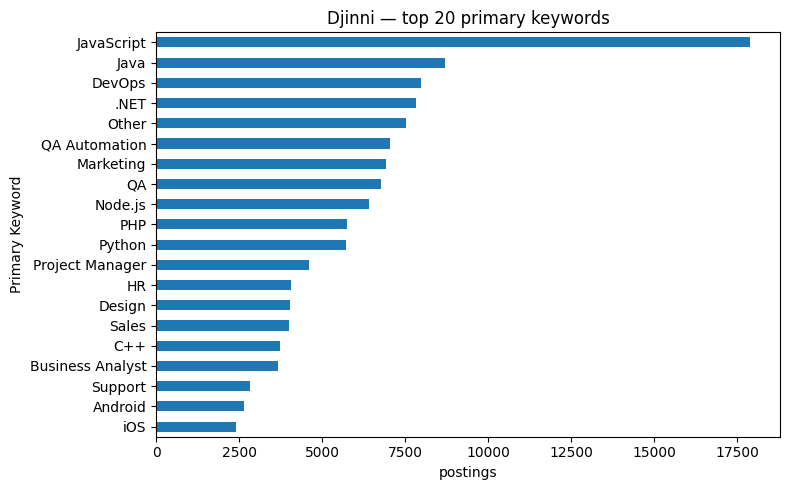

In [8]:
kw = djinni["Primary Keyword"].value_counts()
print(f"{kw.size} distinct primary keywords (tech / domain)\n")
print(kw.head(15))

ax = kw.head(20).iloc[::-1].plot.barh(
    figsize=(8, 5), title="Djinni — top 20 primary keywords")
ax.set_xlabel("postings")
plt.tight_layout()
plt.show()

In [9]:
print("Experience required:")
print(djinni["Exp Years"].value_counts(), "\n")
print("English level required:")
print(djinni["English Level"].value_counts(dropna=False))

Experience required:
Exp Years
3y        49996
2y        36150
5y        27772
1y        22007
no_exp     5972
Name: count, dtype: int64 

English level required:
English Level
upper           66948
intermediate    54965
fluent          10583
NaN              7539
pre              1689
basic             173
Name: count, dtype: int64


## 3. LinkedIn — out-of-domain test set

[Kaggle: LinkedIn Job Postings 2023–2024](https://www.kaggle.com/datasets/arshkon/linkedin-job-postings)
— real, **cross-industry** postings. This set is held out entirely from training
and used only to measure how well an IT-trained model **generalises** to other
domains.

In [10]:
linkedin_dir = JOBS / "linkedin"
keep = ["job_id", "title", "description", "company_name", "location",
        "formatted_work_type", "formatted_experience_level", "skills_desc"]
linkedin = pd.read_csv(linkedin_dir / "postings.csv", usecols=keep)

print(f"shape: {linkedin.shape[0]:,} rows x {linkedin.shape[1]} columns")
linkedin.head(3)

shape: 123,849 rows x 8 columns


,job_id,company_name,title,description,location,formatted_work_type,formatted_experience_level,skills_desc
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in New Jersey is seeking an administrative Marketing Coordinator with some...,"Princeton, NJ",Full-time,NaN,Requirements: \n\nWe are seeking a College or Graduate Student (can also be completed with school) with a focus in P...
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committed to serving clients with best practices to help them with change, im...","Fort Collins, CO",Full-time,NaN,NaN
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting applications for an Assistant Restaurant Manager.\nWe offer highly competitive wa...,"Cincinnati, OH",Full-time,NaN,We are currently accepting resumes for FOH - Asisstant Restaurant Management with a strong focus on delivering high ...


In [11]:
print(f"rows                : {len(linkedin):,}")
print(f"unique descriptions : {linkedin['description'].nunique():,}")
print(f"non-null description: {linkedin['description'].notna().sum():,}")
print(f"non-null skills_desc: {linkedin['skills_desc'].notna().sum():,}  "
      f"({linkedin['skills_desc'].notna().mean():.1%})")
print()
print("description length (chars):")
print(linkedin["description"].str.len().describe().round(0))

rows                : 123,849


unique descriptions : 107,827
non-null description: 123,842
non-null skills_desc: 2,439  (2.0%)

description length (chars):
count    123842.0
mean       3766.0
std        2146.0
min           2.0
25%        2176.0
50%        3435.0
75%        4986.0
max       23201.0
Name: description, dtype: float64


`skills_desc` is populated for only ~2% of postings, so it cannot be relied on as a
skills field. The description text itself is rich, and two auxiliary tables provide
structured tags: `jobs/job_skills.csv` (skill categories) and
`jobs/job_industries.csv` (industry), each resolved through the `mappings/` lookups.

In [12]:
# skills_desc is almost always empty -> use the auxiliary skill / industry tables.
skill_name = (pd.read_csv(linkedin_dir / "mappings" / "skills.csv")
                .set_index("skill_abr")["skill_name"])
job_skills = pd.read_csv(linkedin_dir / "jobs" / "job_skills.csv")
job_skills["skill_name"] = job_skills["skill_abr"].map(skill_name)
skills_per_job = job_skills.groupby("job_id")["skill_name"].apply(list)

industry_name = (pd.read_csv(linkedin_dir / "mappings" / "industries.csv")
                   .set_index("industry_id")["industry_name"])
job_industries = pd.read_csv(linkedin_dir / "jobs" / "job_industries.csv")
job_industries["industry_name"] = job_industries["industry_id"].map(industry_name)

print(f"jobs with >=1 skill tag: {skills_per_job.size:,}")
print(f"distinct skill tags    : {skill_name.size}")
print(f"distinct industries    : {industry_name.size}\n")
print("Top 15 industries (LinkedIn is cross-industry, unlike IT-only Djinni):")
print(job_industries["industry_name"].value_counts().head(15))

jobs with >=1 skill tag: 126,807
distinct skill tags    : 35
distinct industries    : 422

Top 15 industries (LinkedIn is cross-industry, unlike IT-only Djinni):
industry_name
Hospitals and Health Care             18326
Retail                                11033
IT Services and IT Consulting         10396
Staffing and Recruiting                9005
Financial Services                     8535
Software Development                   5091
Manufacturing                          3689
Construction                           3445
Banking                                2923
Insurance                              2673
Pharmaceutical Manufacturing           2469
Hospitality                            2455
Telecommunications                     2433
Real Estate                            2326
Industrial Machinery Manufacturing     2143
Name: count, dtype: int64


## 4. Conclusion — dataset decision

| Dataset | Rows | Unique descriptions | Verdict |
|---|---|---|---|
| Synthetic CSV (provided) | ~1.6M | **376** | Dropped — templated; only ~376 real targets |
| **Djinni** (IT) | 141,897 | **141,897** | **Core** — train / val / in-domain test |
| **LinkedIn** (cross-industry) | 123,849 | 107,827 | **Out-of-domain test** only |

**Decision.** Train and validate on Djinni; reserve LinkedIn as an unseen
cross-industry test set. This yields a genuine generalisation experiment:
*does an IT-trained job-description generator transfer to other industries?*

**Next steps.** Stage 2 — cleaning (length / language filtering, deduplication,
joining the LinkedIn auxiliary tables) — then Stage 3, synthetic recruiter-query
generation with a teacher LLM.